In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [6]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# cleaning missing data
df["Age"] = df["Age"].fillna(df["Age"].median())

df.drop("Cabin",axis = 1, inplace=True)

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [12]:
#  encoding variables
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

ohe = OneHotEncoder(sparse_output = False)
encoded = ohe.fit_transform(df[["Embarked"]])
encoded_df = pd.DataFrame(
    encoded,
    columns = ohe.get_feature_names_out(["Embarked"])
)

df = pd.concat([df.drop("Embarked" , axis=1),encoded_df], axis=1)
                                      

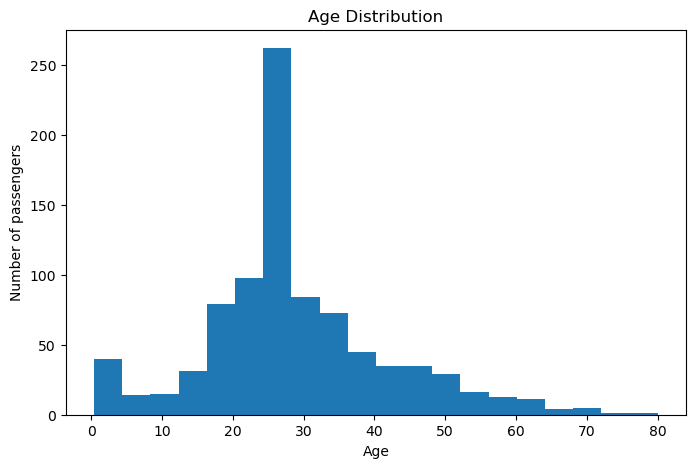

In [14]:
# visualizing age distribution
plt.figure(figsize=(8,5))
plt.hist(df["Age"] , bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.show()

In [15]:
#  save cleaned data
df.to_csv("Titanic_Cleaned.csv" , index=False)
print("Cleaned data saved successfully")

Cleaned data saved successfully
